In [1]:
import pandas as pd
import glob
import os

# raw_data 디렉토리로 이동
os.chdir('raw_data')

def combine_chatbot_data():
    """
    각 챗봇별로 모든 CSV 파일을 합쳐서 하나의 데이터프레임으로 만듭니다.
    """
    chatbots = ['chatgpt', 'claude', 'gemini', 'grok']
    combined_data = {}

    for chatbot in chatbots:
        print(f"Processing {chatbot} data...")

        # 해당 챗봇 폴더의 모든 CSV 파일 경로 가져오기
        csv_files = glob.glob(f"{chatbot}/*.csv")

        if not csv_files:
            print(f"No CSV files found for {chatbot}")
            continue

        # 모든 CSV 파일을 데이터프레임으로 읽어서 리스트에 저장
        dataframes = []
        for file in csv_files:
            try:
                df = pd.read_csv(file)
                df['source_file'] = os.path.basename(file)  # 원본 파일명 추가
                dataframes.append(df)
                print(f"  - Loaded {file}: {len(df)} rows")
            except Exception as e:
                print(f"  - Error loading {file}: {e}")

        if dataframes:
            # 모든 데이터프레임 합치기
            combined_df = pd.concat(dataframes, ignore_index=True)
            combined_df['chatbot'] = chatbot  # 챗봇 이름 컬럼 추가
            combined_data[chatbot] = combined_df

            print(f"  - Combined {chatbot} data: {len(combined_df)} total rows")
        else:
            print(f"  - No valid data found for {chatbot}")

    return combined_data

# 데이터 합치기 실행
combined_data = combine_chatbot_data()

Processing chatgpt data...
  - Loaded chatgpt/2025_5_chatgpt.csv: 9442 rows
  - Loaded chatgpt/chatgpt_2024_11.csv: 2749 rows
  - Loaded chatgpt/chatgpt_2024_12.csv: 3733 rows
  - Loaded chatgpt/2025_6_chatgpt.csv: 10377 rows
  - Loaded chatgpt/chatgpt_2025_4.csv: 9159 rows
  - Loaded chatgpt/chatgpt_2025_1.csv: 2992 rows
  - Loaded chatgpt/chatgpt_2025_3.csv: 5491 rows
  - Loaded chatgpt/chatgpt_2025_2.csv: 2435 rows
  - Loaded chatgpt/2025_5_2_chatgpt.csv: 6741 rows
  - Combined chatgpt data: 53119 total rows
Processing claude data...
  - Loaded claude/claude_2024_11.csv: 1236 rows
  - Loaded claude/claude_2024_12.csv: 2801 rows
  - Loaded claude/2025_5_2_claude.csv: 4323 rows
  - Loaded claude/2025_6_claude.csv: 3104 rows
  - Loaded claude/claude_2025_1.csv: 1482 rows
  - Loaded claude/claude_2025_3.csv: 2515 rows
  - Loaded claude/claude_2025_2.csv: 3082 rows
  - Loaded claude/claude_2025_4.csv: 3154 rows
  - Loaded claude/2025_5_claude.csv: 2459 rows
  - Combined claude data: 2415

In [2]:
# 데이터 요약 정보 출력
def get_data_summary(combined_data):
    """
    각 챗봇별 데이터 요약 정보를 출력합니다.
    """
    print("\n=== 데이터 요약 ===")
    for chatbot, df in combined_data.items():
        print(f"\n{chatbot.upper()}:")
        print(f"  - 총 행 수: {len(df):,}")
        print(f"  - 컬럼: {list(df.columns)}")
        print(f"  - Post ID 수: {df['Post_ID'].nunique():,}")
        print(f"  - Type 분포:")
        print(df['Type'].value_counts().to_string().replace('\n', '\n    '))
        
        # 날짜 범위 확인
        if 'Timestamp' in df.columns:
            df['Timestamp'] = pd.to_datetime(df['Timestamp'])
            print(f"  - 날짜 범위: {df['Timestamp'].min()} ~ {df['Timestamp'].max()}")

# 요약 정보 출력
get_data_summary(combined_data)


=== 데이터 요약 ===

CHATGPT:
  - 총 행 수: 53,119
  - 컬럼: ['Post_ID', 'Type', 'Data', 'Timestamp', 'source_file', 'chatbot']
  - Post ID 수: 127
  - Type 분포:
Type
    2    52946
    0      127
    1       46
  - 날짜 범위: 2024-11-03 03:00:48 ~ 2025-06-20 20:28:18

CLAUDE:
  - 총 행 수: 24,156
  - 컬럼: ['Post_ID', 'Type', 'Data', 'Timestamp', 'source_file', 'chatbot']
  - Post ID 수: 123
  - Type 분포:
Type
    2    23987
    0      123
    1       46
  - 날짜 범위: 2024-11-21 02:32:18 ~ 2025-06-20 19:22:35

GEMINI:
  - 총 행 수: 23,549
  - 컬럼: ['Post_ID', 'Type', 'Data', 'Timestamp', 'source_file', 'chatbot']
  - Post ID 수: 125
  - Type 분포:
Type
    2    23389
    0      125
    1       35
  - 날짜 범위: 2024-11-13 13:00:36 ~ 2025-06-20 20:47:32

GROK:
  - 총 행 수: 32,175
  - 컬럼: ['Post_ID', 'Type', 'Data', 'Timestamp', 'source_file', 'chatbot']
  - Post ID 수: 143
  - Type 분포:
Type
    2    32023
    0      143
    1        9
  - 날짜 범위: 2024-11-12 22:10:09 ~ 2025-06-20 20:35:37


In [3]:
# 각 챗봇별 데이터프레임 저장
chatgpt_df = combined_data['chatgpt']
claude_df = combined_data['claude'] 
gemini_df = combined_data['gemini']
grok_df = combined_data['grok']

print("각 챗봇별 데이터프레임이 생성되었습니다:")
print(f"chatgpt_df: {len(chatgpt_df)} rows")
print(f"claude_df: {len(claude_df)} rows") 
print(f"gemini_df: {len(gemini_df)} rows")
print(f"grok_df: {len(grok_df)} rows")

각 챗봇별 데이터프레임이 생성되었습니다:
chatgpt_df: 53119 rows
claude_df: 24156 rows
gemini_df: 23549 rows
grok_df: 32175 rows


In [ ]:
# 전체 데이터 vs 필터링 후 데이터 비교 + Single/Multi 모델 분석
total_counts = {}

# 전체 데이터 개수 (combined_data에서)
for chatbot, df in combined_data.items():
    total_counts[chatbot.upper()] = len(df)

print("전체 데이터 개수:", sum(total_counts.values()))
print("라벨링된 데이터 개수:", len(labeled_df))

# category 컬럼 분석 (single vs multi)
print("\nCategory 컬럼 분석:")
print(labeled_df['category'].head(10))

# category를 single/multi로 분류
def categorize_models(category_str):
    try:
        # 문자열을 튜플로 변환
        category_tuple = eval(category_str)
        if len(category_tuple) == 1:
            return 'Single'
        else:
            return 'Multi'
    except:
        return 'Unknown'

labeled_df['model_type'] = labeled_df['category'].apply(categorize_models)
model_type_counts = labeled_df['model_type'].value_counts()

print("\nSingle vs Multi 모델 분포:")
print(model_type_counts)

# 시각화 - 두 개의 그래프
plt.figure(figsize=(15, 6))

# 첫 번째 그래프: 데이터 감소량 시각화
plt.subplot(1, 2, 1)
models = ['TOTAL']
original = [sum(total_counts.values())]
filtered = [len(labeled_df)]
reduction = [original[0] - filtered[0]]

x = np.arange(len(models))
width = 0.35

bars1 = plt.bar(x - width/2, original, width, label='Original Data', color='lightcoral', alpha=0.8)
bars2 = plt.bar(x + width/2, filtered, width, label='Filtered Data', color='lightblue', alpha=0.8)

# 값 표시
for i, (orig, filt, red) in enumerate(zip(original, filtered, reduction)):
    plt.text(i - width/2, orig + 1000, f'{orig:,}', ha='center', va='bottom', fontweight='bold')
    plt.text(i + width/2, filt + 1000, f'{filt:,}', ha='center', va='bottom', fontweight='bold')
    
    # 감소량과 비율 표시
    reduction_pct = (red / orig) * 100
    plt.text(i, max(orig, filt) + 5000, f'Reduced: {red:,}\n({reduction_pct:.1f}%)', 
             ha='center', va='bottom', fontsize=10, fontweight='bold', 
             bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.xlabel('Dataset', fontweight='bold')
plt.ylabel('Data Count', fontweight='bold')
plt.title('Data Reduction After Filtering', fontsize=14, fontweight='bold')
plt.xticks(x, models)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# 두 번째 그래프: Single vs Multi 모델 비율
plt.subplot(1, 2, 2)
labels = model_type_counts.index
sizes = model_type_counts.values
colors = ['#FF6B9D', '#4ECDC4']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90,
        textprops={'fontweight': 'bold'})
plt.title('Single vs Multi Model Distribution', fontsize=14, fontweight='bold')

# 범례에 개수 추가
legend_labels = [f'{label}: {count:,}' for label, count in zip(labels, sizes)]
plt.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

# 상세 통계 출력
print("\n=== 데이터 감소 통계 ===")
total_original = sum(total_counts.values())
total_filtered = len(labeled_df)
reduction_count = total_original - total_filtered
reduction_pct = (reduction_count / total_original) * 100

print(f"원본 데이터: {total_original:,}개")
print(f"필터링 후: {total_filtered:,}개")
print(f"감소량: {reduction_count:,}개 ({reduction_pct:.2f}%)")
print(f"유지율: {(total_filtered/total_original)*100:.2f}%")

print("\n=== Single vs Multi 모델 통계 ===")
for model_type, count in model_type_counts.items():
    percentage = (count / len(labeled_df)) * 100
    print(f"{model_type}: {count:,}개 ({percentage:.2f}%)")

# category별 상세 분석
print("\n=== Category 상세 분석 ===")
category_counts = labeled_df['category'].value_counts().head(10)
print("상위 10개 카테고리:")
for category, count in category_counts.items():
    print(f"{category}: {count:,}개")

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np
import platform


# 그래프 스타일 설정
sns.set_style("whitegrid")
plt.style.use('default')

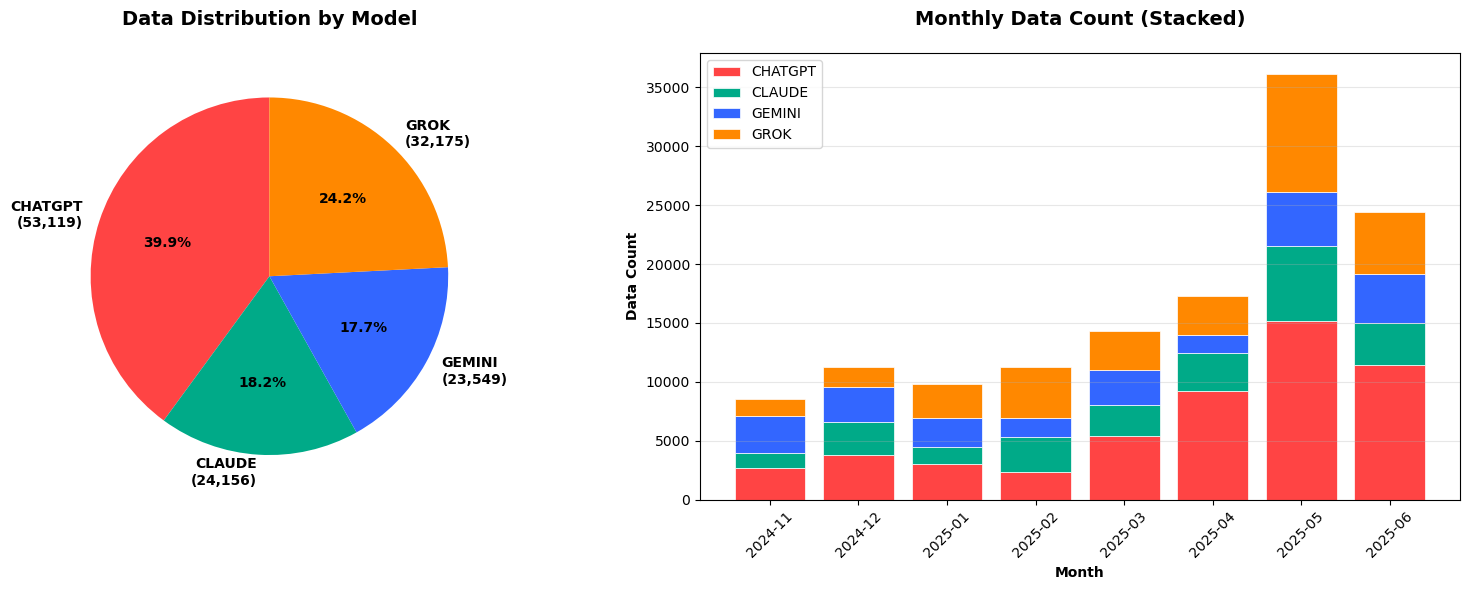

=== 모델별 데이터 개수 ===
CHATGPT: 53,119개
CLAUDE: 24,156개
GEMINI: 23,549개
GROK: 32,175개
전체: 132,999개

=== 월별 데이터 개수 ===
chatbot     CHATGPT  CLAUDE  GEMINI   GROK
year_month                                
2024-11        2727    1236    3129   1427
2024-12        3755    2801    3012   1682
2025-01        2991    1471    2490   2906
2025-02        2369    2978    1618   4297
2025-03        5449    2621    2952   3267
2025-04        9259    3163    1536   3308
2025-05       15141    6352    4588  10036
2025-06       11428    3534    4224   5252

월별 총합:
year_month
2024-11     8519
2024-12    11250
2025-01     9858
2025-02    11262
2025-03    14289
2025-04    17266
2025-05    36117
2025-06    24438
dtype: int64


In [9]:
# 1. 각 모델별 데이터 갯수 시각화 - 파이차트와 누적 바차트 함께
model_counts = {}
for chatbot, df in combined_data.items():
    model_counts[chatbot.upper()] = len(df)

# 월별 데이터 준비
monthly_data = []
for chatbot, df in combined_data.items():
    df_copy = df.copy()
    df_copy['Timestamp'] = pd.to_datetime(df_copy['Timestamp'])
    df_copy['year_month'] = df_copy['Timestamp'].dt.to_period('M')
    monthly_counts = df_copy['year_month'].value_counts().sort_index()
    
    for month, count in monthly_counts.items():
        monthly_data.append({
            'chatbot': chatbot.upper(),
            'year_month': str(month),
            'count': count
        })

monthly_df = pd.DataFrame(monthly_data)
pivot_monthly = monthly_df.pivot(index='year_month', columns='chatbot', values='count').fillna(0)

# 두 그래프를 하나의 figure에 표시
plt.figure(figsize=(16, 6))

# 색상을 더 구분하기 쉽게 변경
colors = ['#FF4444', '#00AA88', '#3366FF', '#FF8800']  # 빨강, 초록, 파랑, 주황

# 서브플롯 1: 파이 차트
plt.subplot(1, 2, 1)
labels_with_count = [f'{model}\n({count:,})' for model, count in model_counts.items()]
plt.pie(model_counts.values(), labels=labels_with_count, autopct='%1.1f%%',
        colors=colors, startangle=90, textprops={'fontweight': 'bold'})
plt.title('Data Distribution by Model', fontsize=14, fontweight='bold', pad=20)

# 서브플롯 2: 누적 바 차트
plt.subplot(1, 2, 2)
bottom = np.zeros(len(pivot_monthly))
for i, chatbot in enumerate(pivot_monthly.columns):
    plt.bar(range(len(pivot_monthly)), pivot_monthly[chatbot], 
            bottom=bottom, label=chatbot, color=colors[i % len(colors)], 
            edgecolor='white', linewidth=0.5)
    bottom += pivot_monthly[chatbot]

plt.title('Monthly Data Count (Stacked)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Data Count', fontweight='bold')
plt.xticks(range(len(pivot_monthly)), pivot_monthly.index, rotation=45)
plt.legend(fontsize=10, loc='upper left')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 수치 출력
print("=== 모델별 데이터 개수 ===")
for model, count in model_counts.items():
    print(f"{model}: {count:,}개")
total = sum(model_counts.values())
print(f"전체: {total:,}개")

print("\n=== 월별 데이터 개수 ===")
print(pivot_monthly)
print(f"\n월별 총합:")
print(pivot_monthly.sum(axis=1))

🚀 데이터 분석 시작...
✅ 데이터 로드 완료: (20176, 7)
📊 컬럼: ['Post_ID', 'Type', 'Data', 'Timestamp', 'category', 'label(chatgpt,claude,grok,gemini)', 'comment']
⚠️ 챗봇 정보를 찾을 수 없습니다.

📈 전체 데이터 개수: 132,999개
📊 라벨링된 데이터 개수: 20,176개

🔍 Category 샘플:
["('chatgpt', 'claude')", "('chatgpt', 'gemini')", "('chatgpt', 'gemini')", "('chatgpt', 'claude')", "('chatgpt', 'claude')", "('chatgpt', 'claude')", "('chatgpt', 'claude')", "('chatgpt', 'claude')", "('chatgpt', 'claude')", "('chatgpt', 'gemini')"]

📊 Single vs Multi 모델 분포:
  - Single: 18,530개 (91.84%)
  - Multi: 1,646개 (8.16%)


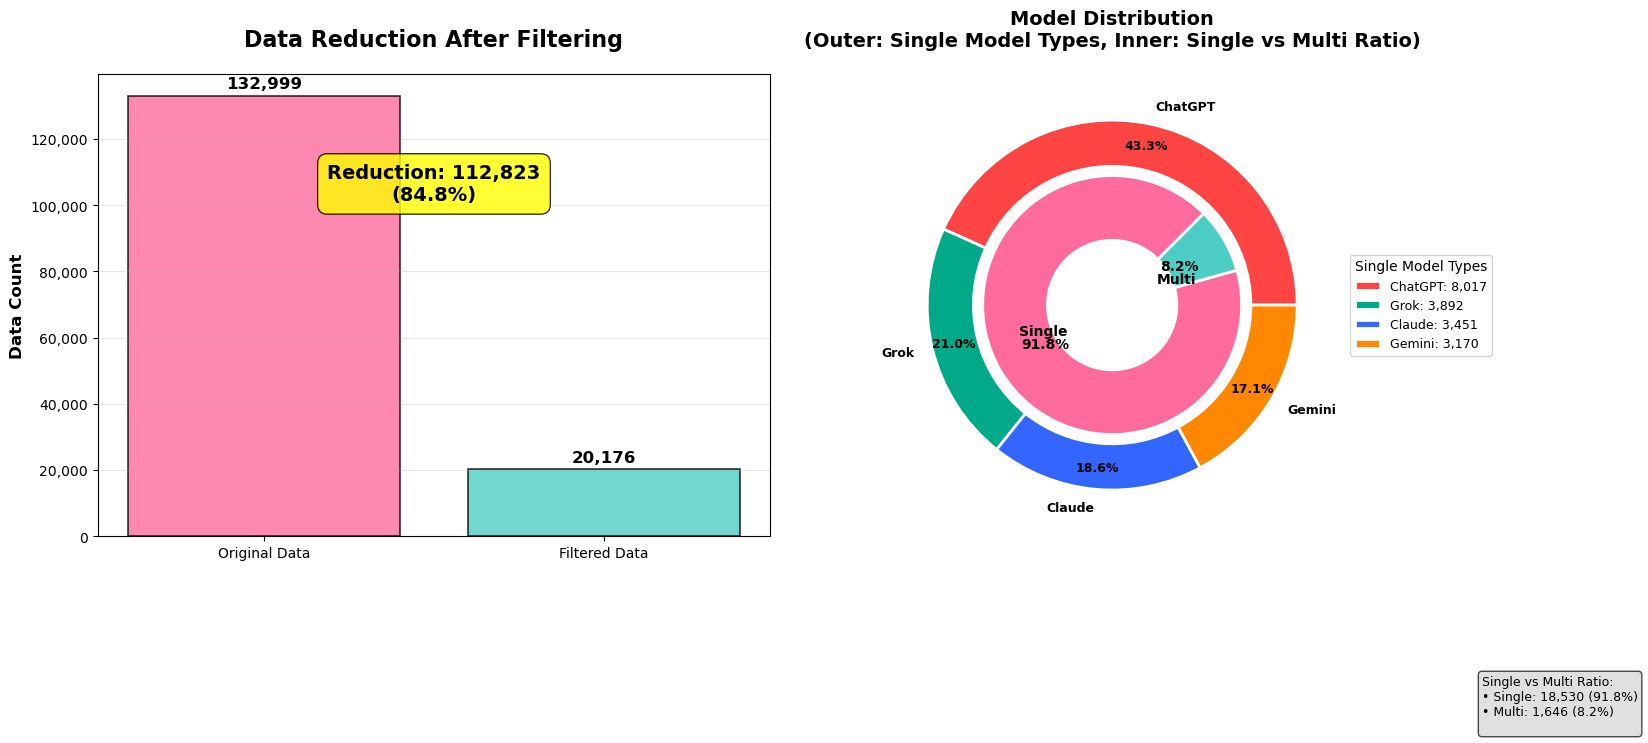


📊 상세 통계 리포트

🔍 데이터 감소 분석:
  • 원본 데이터: 132,999개
  • 필터링 후: 20,176개
  • 감소량: 112,823개 (84.83%)
  • 유지율: 15.17%

🤖 모델 타입 분석:
  • Single: 18,530개 (91.84%)
  • Multi: 1,646개 (8.16%)

📈 상위 카테고리 (Top 10):
   1. ('chatgpt',): 8,017개 (39.74%)
   2. ('grok',): 3,892개 (19.29%)
   3. ('claude',): 3,451개 (17.10%)
   4. ('gemini',): 3,170개 (15.71%)
   5. ('gemini', 'claude'): 525개 (2.60%)
   6. ('chatgpt', 'gemini'): 356개 (1.76%)
   7. ('chatgpt', 'claude'): 288개 (1.43%)
   8. ('chatgpt', 'grok'): 161개 (0.80%)
   9. ('chatgpt', 'gemini', 'claude'): 124개 (0.61%)
  10. ('grok', 'claude'): 45개 (0.22%)

✅ 분석 완료!


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from typing import Dict, Tuple

class DataAnalyzer:
    """데이터 필터링 및 모델 분석을 위한 클래스"""

    def __init__(self, labeled_data_path: str = 'data_labelling/labeled_data.csv'):
        """
        초기화 메서드

        Args:
            labeled_data_path: 라벨링된 데이터 파일 경로
        """
        self.labeled_data_path = labeled_data_path
        self.labeled_df = None
        self.total_counts = {}

    def load_data(self) -> pd.DataFrame:
        """라벨링된 데이터 로드"""
        try:
            # 경로 조정
            if not os.path.exists(self.labeled_data_path):
                os.chdir('..')

            self.labeled_df = pd.read_csv(self.labeled_data_path)
            print(f"✅ 데이터 로드 완료: {self.labeled_df.shape}")
            print(f"📊 컬럼: {self.labeled_df.columns.tolist()}")

            return self.labeled_df

        except FileNotFoundError:
            print(f"❌ 파일을 찾을 수 없습니다: {self.labeled_data_path}")
            return None
        except Exception as e:
            print(f"❌ 데이터 로드 중 오류: {e}")
            return None

    def analyze_chatbot_distribution(self) -> Dict:
        """챗봇별 분포 분석"""
        chatbot_info = {}

        # chatbot 컬럼 찾기
        chatbot_col = None
        for col in self.labeled_df.columns:
            if 'chatbot' in col.lower() or 'model' in col.lower():
                chatbot_col = col
                break

        if chatbot_col:
            chatbot_info = self.labeled_df[chatbot_col].value_counts().to_dict()
            print(f"📈 {chatbot_col} 분포:")
            for bot, count in chatbot_info.items():
                print(f"  - {bot}: {count:,}개")
        else:
            print("⚠️ 챗봇 정보를 찾을 수 없습니다.")

        return chatbot_info

    def categorize_models(self, category_str: str) -> str:
        """카테고리 문자열을 Single/Multi로 분류"""
        try:
            # 안전한 평가를 위한 처리
            if isinstance(category_str, str):
                # 튜플 형태의 문자열을 실제 튜플로 변환
                if category_str.startswith('(') and category_str.endswith(')'):
                    category_tuple = eval(category_str)
                    return 'Single' if len(category_tuple) == 1 else 'Multi'
                # 리스트 형태나 기타 형태 처리
                elif ',' in category_str:
                    return 'Multi'
                else:
                    return 'Single'
            return 'Unknown'
        except Exception as e:
            print(f"⚠️ 카테고리 분류 오류: {e}")
            return 'Unknown'

    def analyze_model_types(self) -> Dict:
        """Single vs Multi 모델 분석"""
        if 'category' not in self.labeled_df.columns:
            print("❌ 'category' 컬럼이 없습니다.")
            return {}

        print("\n🔍 Category 샘플:")
        print(self.labeled_df['category'].head(10).tolist())

        # 모델 타입 분류
        self.labeled_df['model_type'] = self.labeled_df['category'].apply(self.categorize_models)
        model_type_counts = self.labeled_df['model_type'].value_counts()

        print(f"\n📊 Single vs Multi 모델 분포:")
        for model_type, count in model_type_counts.items():
            percentage = (count / len(self.labeled_df)) * 100
            print(f"  - {model_type}: {count:,}개 ({percentage:.2f}%)")

        return model_type_counts.to_dict()

    def set_total_counts(self, combined_data: Dict = None, total_original: int = 132999) -> None:
        """
        전체 데이터 개수 설정

        Args:
            combined_data: 챗봇별 데이터 딕셔너리 (옵션)
            total_original: 전체 원본 데이터 개수 (기본값: 132,999)
        """
        if combined_data:
            self.total_counts = {chatbot.upper(): len(df) for chatbot, df in combined_data.items()}
        else:
            # 기본값 사용 (전체 데이터 132,999개)
            self.total_counts = {'TOTAL': total_original}

        print(f"\n📈 전체 데이터 개수: {sum(self.total_counts.values()):,}개")
        print(f"📊 라벨링된 데이터 개수: {len(self.labeled_df):,}개")

    def create_visualizations(self) -> None:
        """데이터 분석 시각화"""
        if self.labeled_df is None:
            print("❌ 데이터가 로드되지 않았습니다.")
            return

        # 한글 폰트 설정
        plt.rcParams['font.family'] = 'DejaVu Sans'
        plt.rcParams['axes.unicode_minus'] = False

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

        # 1. 데이터 감소량 시각화
        self._plot_data_reduction(ax1)

        # 2. 이중 도넛 차트 (모델 타입 + 챗봇 분포)
        self._plot_combined_distribution(ax2)

        plt.tight_layout()
        plt.show()

    def _plot_data_reduction(self, ax) -> None:
        """데이터 감소량 시각화"""
        total_original = sum(self.total_counts.values()) if self.total_counts else 0
        total_filtered = len(self.labeled_df)
        reduction_count = total_original - total_filtered
        reduction_pct = (reduction_count / total_original * 100) if total_original > 0 else 0

        categories = ['Original Data', 'Filtered Data']
        values = [total_original, total_filtered]
        colors = ['#FF6B9D', '#4ECDC4']

        bars = ax.bar(categories, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)

        # 값 표시
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + max(values) * 0.01,
                   f'{value:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)

        # 감소량 표시
        if total_original > 0:
            ax.text(0.5, max(values) * 0.8,
                   f'Reduction: {reduction_count:,}\n({reduction_pct:.1f}%)',
                   ha='center', va='center', fontsize=14, fontweight='bold',
                   bbox=dict(boxstyle="round,pad=0.5", facecolor="yellow", alpha=0.8))

        ax.set_title('Data Reduction After Filtering', fontsize=16, fontweight='bold', pad=20)
        ax.set_ylabel('Data Count', fontweight='bold', fontsize=12)
        ax.grid(True, alpha=0.3, axis='y')

        # y축 포맷팅
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

    def _plot_combined_distribution(self, ax) -> None:
        """이중 도넛 차트 (외부: Single 모델별 분포, 내부: Single vs Multi 비율)"""

        # 챗봇 분포 데이터 (외부 링에 표시 - Single 모델들만)
        chatbot_data = {
            'ChatGPT': 8017,
            'Grok': 3892,
            'Claude': 3451,
            'Gemini': 3170
        }

        # 모델 타입 분포 (내부 링에 표시)
        model_counts = self.labeled_df['model_type'].value_counts() if 'model_type' in self.labeled_df.columns else {}

        if not model_counts.empty:
            # 색상 설정
            chatbot_colors = ['#FF4444', '#00AA88', '#3366FF', '#FF8800']
            model_colors = ['#FF6B9D', '#4ECDC4', '#FFA726'][:len(model_counts)]

            # 외부 링: 챗봇별 분포 (Single 모델들)
            wedges1, texts1, autotexts1 = ax.pie(
                chatbot_data.values(),
                labels=list(chatbot_data.keys()),
                autopct='%1.1f%%',
                colors=chatbot_colors,
                radius=1.0,
                wedgeprops=dict(width=0.25, edgecolor='white', linewidth=2),
                textprops={'fontsize': 9, 'fontweight': 'bold'},
                pctdistance=0.88,
                labeldistance=1.1
            )

            # 내부 링: 모델 타입 분포
            wedges2, texts2, autotexts2 = ax.pie(
                model_counts.values,
                labels=model_counts.index,
                autopct='%1.1f%%',
                colors=model_colors,
                radius=0.7,
                wedgeprops=dict(width=0.35, edgecolor='white', linewidth=2),
                textprops={'fontsize': 10, 'fontweight': 'bold'},
                pctdistance=0.6,
                labeldistance=0.4,
                startangle=45  # 시작 각도 조정으로 겹침 방지
            )

            # 제목
            ax.set_title('Model Distribution\n(Outer: Single Model Types, Inner: Single vs Multi Ratio)',
                        fontsize=14, fontweight='bold', pad=20)

            # 범례 - 챗봇 (Single 모델들)
            chatbot_legend = [f'{name}: {count:,}' for name, count in chatbot_data.items()]
            ax.legend(wedges1, chatbot_legend, title="Single Model Types",
                     loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=9)

            # 범례 - 모델 타입 (텍스트로 추가)
            model_legend_text = "Single vs Multi Ratio:\n"
            for model_type, count in model_counts.items():
                percentage = (count / len(self.labeled_df)) * 100
                model_legend_text += f"• {model_type}: {count:,} ({percentage:.1f}%)\n"

            ax.text(1.3, -0.3, model_legend_text, transform=ax.transAxes,
                   fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))

        else:
            # 모델 타입 데이터가 없는 경우 챗봇 분포만 표시
            wedges, texts, autotexts = ax.pie(
                chatbot_data.values(),
                labels=list(chatbot_data.keys()),
                autopct='%1.1f%%',
                colors=chatbot_colors,
                textprops={'fontweight': 'bold', 'fontsize': 12}
            )

            ax.set_title('Single Model Distribution', fontsize=16, fontweight='bold', pad=20)

            # 범례
            legend_labels = [f'{name}: {count:,}' for name, count in chatbot_data.items()]
            ax.legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)

    def print_detailed_statistics(self) -> None:
        """상세 통계 출력"""
        print("\n" + "="*50)
        print("📊 상세 통계 리포트")
        print("="*50)

        # 데이터 감소 통계
        total_original = sum(self.total_counts.values()) if self.total_counts else 0
        total_filtered = len(self.labeled_df)

        if total_original > 0:
            reduction_count = total_original - total_filtered
            reduction_pct = (reduction_count / total_original) * 100
            retention_pct = (total_filtered / total_original) * 100

            print(f"\n🔍 데이터 감소 분석:")
            print(f"  • 원본 데이터: {total_original:,}개")
            print(f"  • 필터링 후: {total_filtered:,}개")
            print(f"  • 감소량: {reduction_count:,}개 ({reduction_pct:.2f}%)")
            print(f"  • 유지율: {retention_pct:.2f}%")

        # 모델 타입 통계
        if 'model_type' in self.labeled_df.columns:
            model_type_counts = self.labeled_df['model_type'].value_counts()
            print(f"\n🤖 모델 타입 분석:")
            for model_type, count in model_type_counts.items():
                percentage = (count / len(self.labeled_df)) * 100
                print(f"  • {model_type}: {count:,}개 ({percentage:.2f}%)")

        # 카테고리 상세 분석
        if 'category' in self.labeled_df.columns:
            print(f"\n📈 상위 카테고리 (Top 10):")
            category_counts = self.labeled_df['category'].value_counts().head(10)
            for i, (category, count) in enumerate(category_counts.items(), 1):
                percentage = (count / len(self.labeled_df)) * 100
                print(f"  {i:2d}. {str(category)[:50]}: {count:,}개 ({percentage:.2f}%)")

    def run_complete_analysis(self, combined_data: Dict = None) -> None:
        """전체 분석 실행"""
        print("🚀 데이터 분석 시작...")

        # 1. 데이터 로드
        if self.load_data() is None:
            return

        # 2. 챗봇 분포 분석
        self.analyze_chatbot_distribution()

        # 3. 전체 데이터 개수 설정 (기본값: 132,999개 사용)
        self.set_total_counts(combined_data)

        # 4. 모델 타입 분석
        self.analyze_model_types()

        # 5. 시각화
        self.create_visualizations()

        # 6. 상세 통계
        self.print_detailed_statistics()

        print("\n✅ 분석 완료!")

# 사용 예시
if __name__ == "__main__":
    # 분석기 초기화
    analyzer = DataAnalyzer()

    # 방법 1: 기본값(132,999개) 사용
    analyzer.run_complete_analysis()

    # 방법 2: combined_data와 함께 사용
    # combined_data = {'chatbot1': df1, 'chatbot2': df2, ...}
    # analyzer.run_complete_analysis(combined_data=combined_data)

    # 방법 3: 다른 총 개수 지정
    # analyzer.set_total_counts(total_original=150000)  # 다른 값 사용

🚀 라벨링된 Category 분포 분석 시작...
✅ 데이터 로드 완료: 20,176개 행
📋 라벨 컬럼: 'label(chatgpt,claude,grok,gemini)'
📊 라벨링된 Category 데이터 처리 중...

📈 총 15개의 서로 다른 category 조합 발견
📊 라벨링된 데이터 개수: 1,305개
📋 처리 통계:
  • 전체 행: 20,176개
  • 처리됨: 1,305개
  • 라벨 없음: 18,871개
  • 오류: 0개

🔢 모델 조합 길이별 분포:
  1개 모델: 390개 (29.9%)
  2개 모델: 772개 (59.2%)
  3개 모델: 122개 (9.3%)
  4개 모델: 21개 (1.6%)

🏆 전체 카테고리 (15개):
   1. (gemini, claude): 225개 (17.24%)
   2. (chatgpt, claude): 203개 (15.56%)
   3. (chatgpt, gemini): 190개 (14.56%)
   4. (chatgpt): 101개 (7.74%)
   5. (grok): 99개 (7.59%)
   6. (chatgpt, grok): 98개 (7.51%)
   7. (gemini): 96개 (7.36%)
   8. (claude): 94개 (7.20%)
   9. (chatgpt, gemini, claude): 78개 (5.98%)
  10. (grok, claude): 29개 (2.22%)
  11. (gemini, grok): 27개 (2.07%)
  12. (chatgpt, claude, grok, gemini): 21개 (1.61%)
  13. (chatgpt, grok, claude): 17개 (1.30%)
  14. (chatgpt, gemini, grok): 17개 (1.30%)
  15. (gemini, grok, claude): 10개 (0.77%)


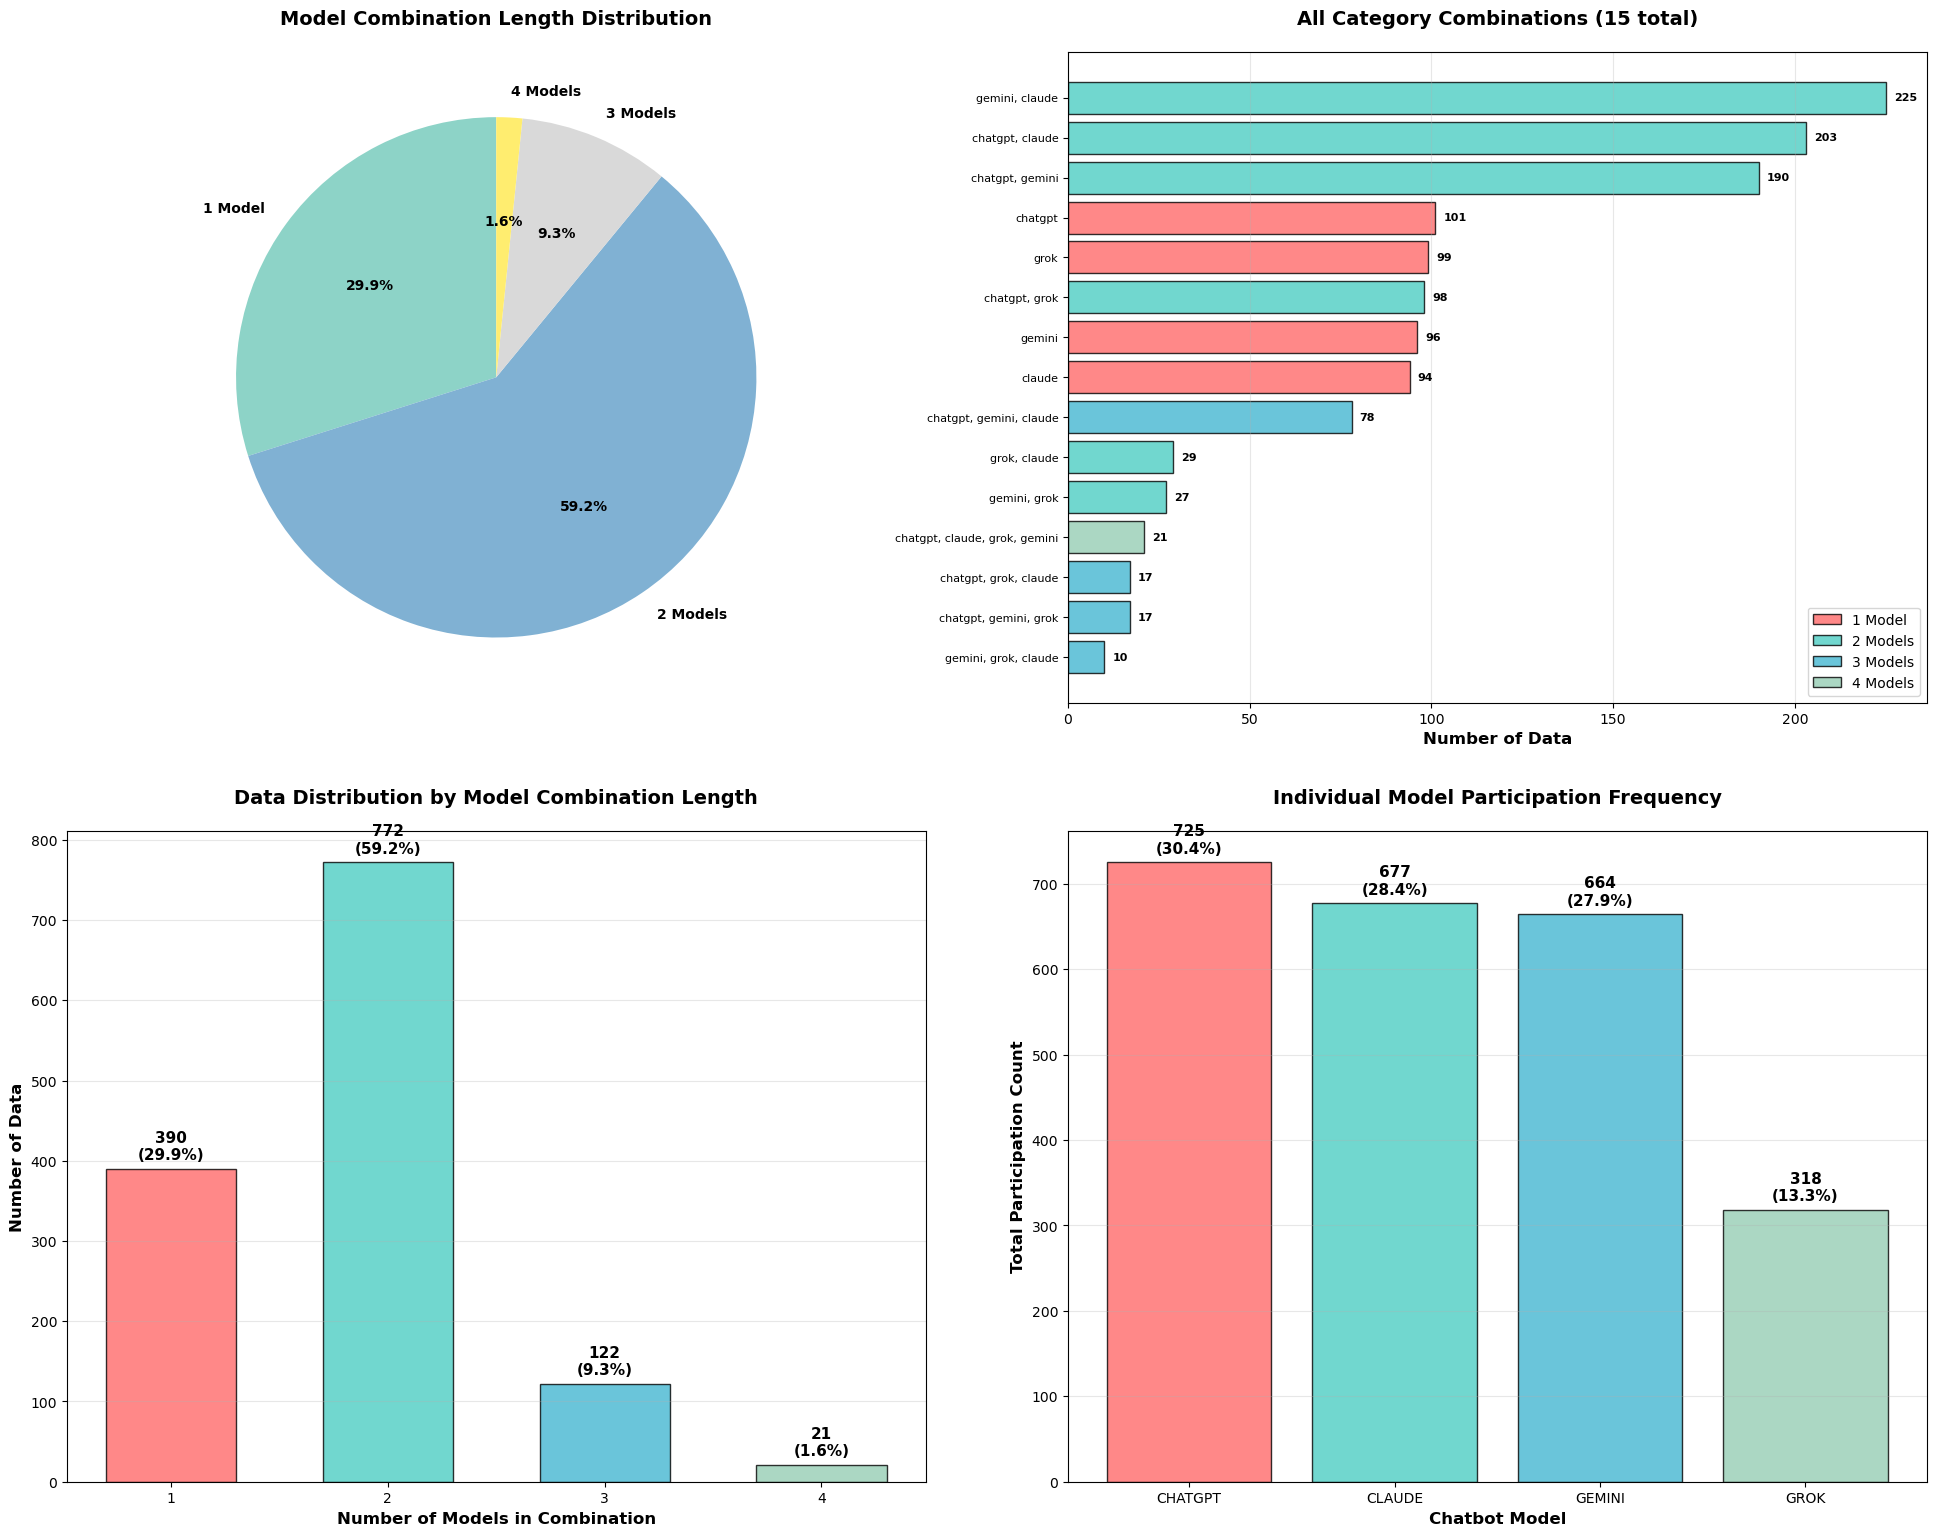


✅ 분석 완료!


In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
from collections import Counter, defaultdict
import seaborn as sns

def analyze_category_distribution(csv_path='data_labelling/labeled_data.csv'):
    """
    라벨링된 Category별 데이터 개수를 분석하고 시각화하는 함수
    """

    # 데이터 로드
    try:
        df = pd.read_csv(csv_path)
        print(f"✅ 데이터 로드 완료: {len(df):,}개 행")
    except FileNotFoundError:
        print(f"❌ 파일을 찾을 수 없습니다: {csv_path}")
        return

    if df.empty:
        print("❌ 데이터프레임이 비어있습니다.")
        return

    # 라벨 컬럼명 확인 및 변경
    label_column = None
    for col in df.columns:
        if 'label' in col.lower():
            label_column = col
            break

    if label_column is None:
        print("❌ 라벨 컬럼을 찾을 수 없습니다.")
        return

    # 라벨 컬럼명 표준화
    if label_column != 'labels':
        df = df.rename(columns={label_column: 'labels'})

    print(f"📋 라벨 컬럼: '{label_column}'")

    # Category 데이터 처리 (라벨링된 데이터만)
    category_counts = Counter()
    model_combo_counts = defaultdict(int)  # 모델 조합별 집계
    total_rows = len(df)
    processed_rows = 0
    skipped_no_label = 0
    skipped_error = 0

    print("📊 라벨링된 Category 데이터 처리 중...")

    for idx, row in df.iterrows():
        try:
            # 라벨 확인 - 라벨이 없으면 스킵
            labels_str = str(row['labels'])
            if labels_str == 'nan' or pd.isna(labels_str) or labels_str == '':
                skipped_no_label += 1
                continue

            # 라벨이 비어있는지 추가 확인
            try:
                labels = ast.literal_eval(labels_str)
                if not labels or all(pd.isna(label) for label in labels):
                    skipped_no_label += 1
                    continue
            except:
                skipped_no_label += 1
                continue

            # Category 처리
            category_str = str(row['category'])
            if category_str == 'nan' or pd.isna(category_str):
                skipped_error += 1
                continue

            # 문자열을 튜플로 변환
            category = ast.literal_eval(category_str)

            if isinstance(category, tuple):
                # 정확한 category 문자열로 카운트
                category_counts[category] += 1

                # 모델 조합 길이별 카운트
                combo_length = len(category)
                model_combo_counts[combo_length] += 1
                processed_rows += 1

        except (ValueError, SyntaxError, TypeError) as e:
            skipped_error += 1
            continue

    # 결과 출력
    print(f"\n📈 총 {len(category_counts)}개의 서로 다른 category 조합 발견")
    print(f"📊 라벨링된 데이터 개수: {sum(category_counts.values()):,}개")
    print(f"📋 처리 통계:")
    print(f"  • 전체 행: {total_rows:,}개")
    print(f"  • 처리됨: {processed_rows:,}개")
    print(f"  • 라벨 없음: {skipped_no_label:,}개")
    print(f"  • 오류: {skipped_error:,}개")

    # 모델 조합 길이별 통계
    print(f"\n🔢 모델 조합 길이별 분포:")
    for length in sorted(model_combo_counts.keys()):
        count = model_combo_counts[length]
        percentage = (count / sum(model_combo_counts.values())) * 100
        print(f"  {length}개 모델: {count:,}개 ({percentage:.1f}%)")

    # 모든 카테고리 출력
    print(f"\n🏆 전체 카테고리 ({len(category_counts)}개):")
    for i, (category, count) in enumerate(category_counts.most_common(), 1):
        percentage = (count / sum(category_counts.values())) * 100
        models = ', '.join(category)
        print(f"  {i:2d}. ({models}): {count:,}개 ({percentage:.2f}%)")

    # 시각화
    create_category_visualizations(category_counts, model_combo_counts)

    return category_counts, model_combo_counts

def create_category_visualizations(category_counts, model_combo_counts):
    """
    Category 분포를 시각화하는 함수
    """

    # 한글 폰트 설정
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False

    # 2x2 서브플롯 생성
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

    # 1. 모델 조합 길이별 분포 (파이 차트)
    plot_combo_length_pie(ax1, model_combo_counts)

    # 2. 상위 카테고리 바 차트
    plot_top_categories_bar(ax2, category_counts)

    # 3. 모델 조합 길이별 분포 (바 차트)
    plot_combo_length_bar(ax3, model_combo_counts)

    # 4. 개별 모델 참여 빈도
    plot_individual_model_frequency(ax4, category_counts)

    plt.tight_layout(pad=3.0)
    plt.show()

def plot_combo_length_pie(ax, model_combo_counts):
    """모델 조합 길이별 파이 차트"""
    lengths = sorted(model_combo_counts.keys())
    counts = [model_combo_counts[length] for length in lengths]
    labels = [f'{length} Model{"s" if length > 1 else ""}' for length in lengths]

    colors = plt.cm.Set3(np.linspace(0, 1, len(lengths)))

    wedges, texts, autotexts = ax.pie(counts, labels=labels, autopct='%1.1f%%',
                                     colors=colors, startangle=90,
                                     textprops={'fontweight': 'bold', 'fontsize': 10})

    ax.set_title('Model Combination Length Distribution',
                fontsize=14, fontweight='bold', pad=20)

def plot_top_categories_bar(ax, category_counts, top_n=None):
    """전체 카테고리 바 차트"""

    # top_n이 None이면 모든 카테고리 표시
    if top_n is None:
        top_n = len(category_counts)

    top_categories = category_counts.most_common(top_n)

    categories = []
    counts = []
    colors = []

    # 색상 매핑 (모델 조합 길이별)
    color_map = {1: '#FF6B6B', 2: '#4ECDC4', 3: '#45B7D1', 4: '#96CEB4'}

    for category, count in top_categories:
        # 카테고리 라벨 생성
        models = ', '.join(category)
        if len(models) > 30:  # 긴 라벨 줄이기
            models = models[:27] + '...'
        categories.append(models)
        counts.append(count)
        colors.append(color_map.get(len(category), '#Gray'))

    # 카테고리가 많으면 가로 막대 그래프, 적으면 세로 막대 그래프
    if len(categories) > 10:
        bars = ax.barh(range(len(categories)), counts, color=colors, alpha=0.8, edgecolor='black')

        # 값 표시
        for i, (bar, count) in enumerate(zip(bars, counts)):
            ax.text(bar.get_width() + max(counts) * 0.01, bar.get_y() + bar.get_height()/2,
                   f'{count:,}', ha='left', va='center', fontweight='bold', fontsize=8)

        ax.set_yticks(range(len(categories)))
        ax.set_yticklabels(categories, fontsize=8)
        ax.set_xlabel('Number of Data', fontweight='bold', fontsize=12)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
        ax.grid(axis='x', alpha=0.3)

        # y축 레이블을 뒤집어서 상위부터 표시
        ax.invert_yaxis()

    else:
        bars = ax.bar(range(len(categories)), counts, color=colors, alpha=0.8, edgecolor='black')

        # 값 표시
        for bar, count in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts) * 0.01,
                   f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)

        ax.set_xticks(range(len(categories)))
        ax.set_xticklabels(categories, rotation=45, ha='right', fontsize=10)
        ax.set_ylabel('Number of Data', fontweight='bold', fontsize=12)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
        ax.grid(axis='y', alpha=0.3)

    ax.set_title(f'All Category Combinations ({len(categories)} total)', fontsize=14, fontweight='bold', pad=20)

    # 범례 추가
    legend_elements = [plt.Rectangle((0,0),1,1, facecolor=color_map[i], alpha=0.8, edgecolor='black')
                      for i in sorted(color_map.keys()) if i in [len(cat) for cat, _ in top_categories]]
    legend_labels = [f'{i} Model{"s" if i > 1 else ""}' for i in sorted(color_map.keys())
                    if i in [len(cat) for cat, _ in top_categories]]

    if legend_elements:
        ax.legend(legend_elements, legend_labels, loc='best', fontsize=10)

def plot_combo_length_bar(ax, model_combo_counts):
    """모델 조합 길이별 바 차트"""
    lengths = sorted(model_combo_counts.keys())
    counts = [model_combo_counts[length] for length in lengths]

    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'][:len(lengths)]

    bars = ax.bar(lengths, counts, color=colors, alpha=0.8, edgecolor='black', width=0.6)

    # 값과 퍼센트 표시
    total = sum(counts)
    for bar, count in zip(bars, counts):
        percentage = (count / total) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts) * 0.01,
               f'{count:,}\n({percentage:.1f}%)', ha='center', va='bottom',
               fontweight='bold', fontsize=11)

    ax.set_xlabel('Number of Models in Combination', fontweight='bold', fontsize=12)
    ax.set_ylabel('Number of Data', fontweight='bold', fontsize=12)
    ax.set_title('Data Distribution by Model Combination Length', fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(lengths)
    ax.grid(axis='y', alpha=0.3)

    # y축 포맷
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

def plot_individual_model_frequency(ax, category_counts):
    """개별 모델 참여 빈도"""
    model_participation = defaultdict(int)

    # 각 모델이 몇 번 참여했는지 계산
    for category, count in category_counts.items():
        for model in category:
            model_participation[model] += count

    models = list(model_participation.keys())
    frequencies = list(model_participation.values())

    # 모델명 대문자로 변환
    models = [model.upper() for model in models]

    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'][:len(models)]

    bars = ax.bar(models, frequencies, color=colors, alpha=0.8, edgecolor='black')

    # 값과 퍼센트 표시
    total = sum(frequencies)
    for bar, freq in zip(bars, frequencies):
        percentage = (freq / total) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(frequencies) * 0.01,
               f'{freq:,}\n({percentage:.1f}%)', ha='center', va='bottom',
               fontweight='bold', fontsize=11)

    ax.set_xlabel('Chatbot Model', fontweight='bold', fontsize=12)
    ax.set_ylabel('Total Participation Count', fontweight='bold', fontsize=12)
    ax.set_title('Individual Model Participation Frequency', fontsize=14, fontweight='bold', pad=20)
    ax.grid(axis='y', alpha=0.3)

    # y축 포맷
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# 상세 분석 함수
def detailed_category_analysis(csv_path='data_labelling/labeled_data.csv'):
    """상세한 카테고리 분석 (라벨링된 데이터만)"""

    category_counts, model_combo_counts = analyze_category_distribution(csv_path)

    print("\n" + "="*60)
    print("📊 라벨링된 데이터 상세 카테고리 분석 리포트")
    print("="*60)

    # 모든 카테고리 출력
    print(f"\n📋 전체 카테고리 목록 ({len(category_counts)}개):")
    for i, (category, count) in enumerate(category_counts.most_common(), 1):
        percentage = (count / sum(category_counts.values())) * 100
        models = ', '.join(category)
        print(f"  {i:2d}. ({models}): {count:,}개 ({percentage:.2f}%)")

    # 조합별 상세 분석
    print(f"\n🔍 모델 조합별 상세 분석:")
    for length in sorted(model_combo_counts.keys()):
        print(f"\n  📌 {length}개 모델 조합:")
        length_categories = [(cat, cnt) for cat, cnt in category_counts.items() if len(cat) == length]
        length_categories.sort(key=lambda x: x[1], reverse=True)

        for category, count in length_categories:
            percentage = (count / sum(category_counts.values())) * 100
            models = ', '.join(category)
            print(f"     • ({models}): {count:,}개 ({percentage:.2f}%)")

# 실행 예시
if __name__ == "__main__":
    print("🚀 라벨링된 Category 분포 분석 시작...")

    # 기본 분석 및 시각화
    category_counts, model_combo_counts = analyze_category_distribution()

    # 상세 분석이 필요한 경우 주석 해제
    # detailed_category_analysis()

    print("\n✅ 분석 완료!")

🚀 Category 분포 분석 시작...
✅ 데이터 로드 완료: 20,176개 행
📊 Category 데이터 처리 중...

📈 총 15개의 서로 다른 category 조합 발견
📊 총 데이터 개수: 20,176개

🔢 모델 조합 길이별 분포:
  1개 모델: 18,530개 (91.8%)
  2개 모델: 1,419개 (7.0%)
  3개 모델: 188개 (0.9%)
  4개 모델: 39개 (0.2%)

🏆 상위 카테고리 (Top 15):
   1. (chatgpt): 8,017개 (39.74%)
   2. (grok): 3,892개 (19.29%)
   3. (claude): 3,451개 (17.10%)
   4. (gemini): 3,170개 (15.71%)
   5. (gemini, claude): 525개 (2.60%)
   6. (chatgpt, gemini): 356개 (1.76%)
   7. (chatgpt, claude): 288개 (1.43%)
   8. (chatgpt, grok): 161개 (0.80%)
   9. (chatgpt, gemini, claude): 124개 (0.61%)
  10. (grok, claude): 45개 (0.22%)
  11. (gemini, grok): 44개 (0.22%)
  12. (chatgpt, claude, grok, gemini): 39개 (0.19%)
  13. (chatgpt, gemini, grok): 29개 (0.14%)
  14. (chatgpt, grok, claude): 22개 (0.11%)
  15. (gemini, grok, claude): 13개 (0.06%)


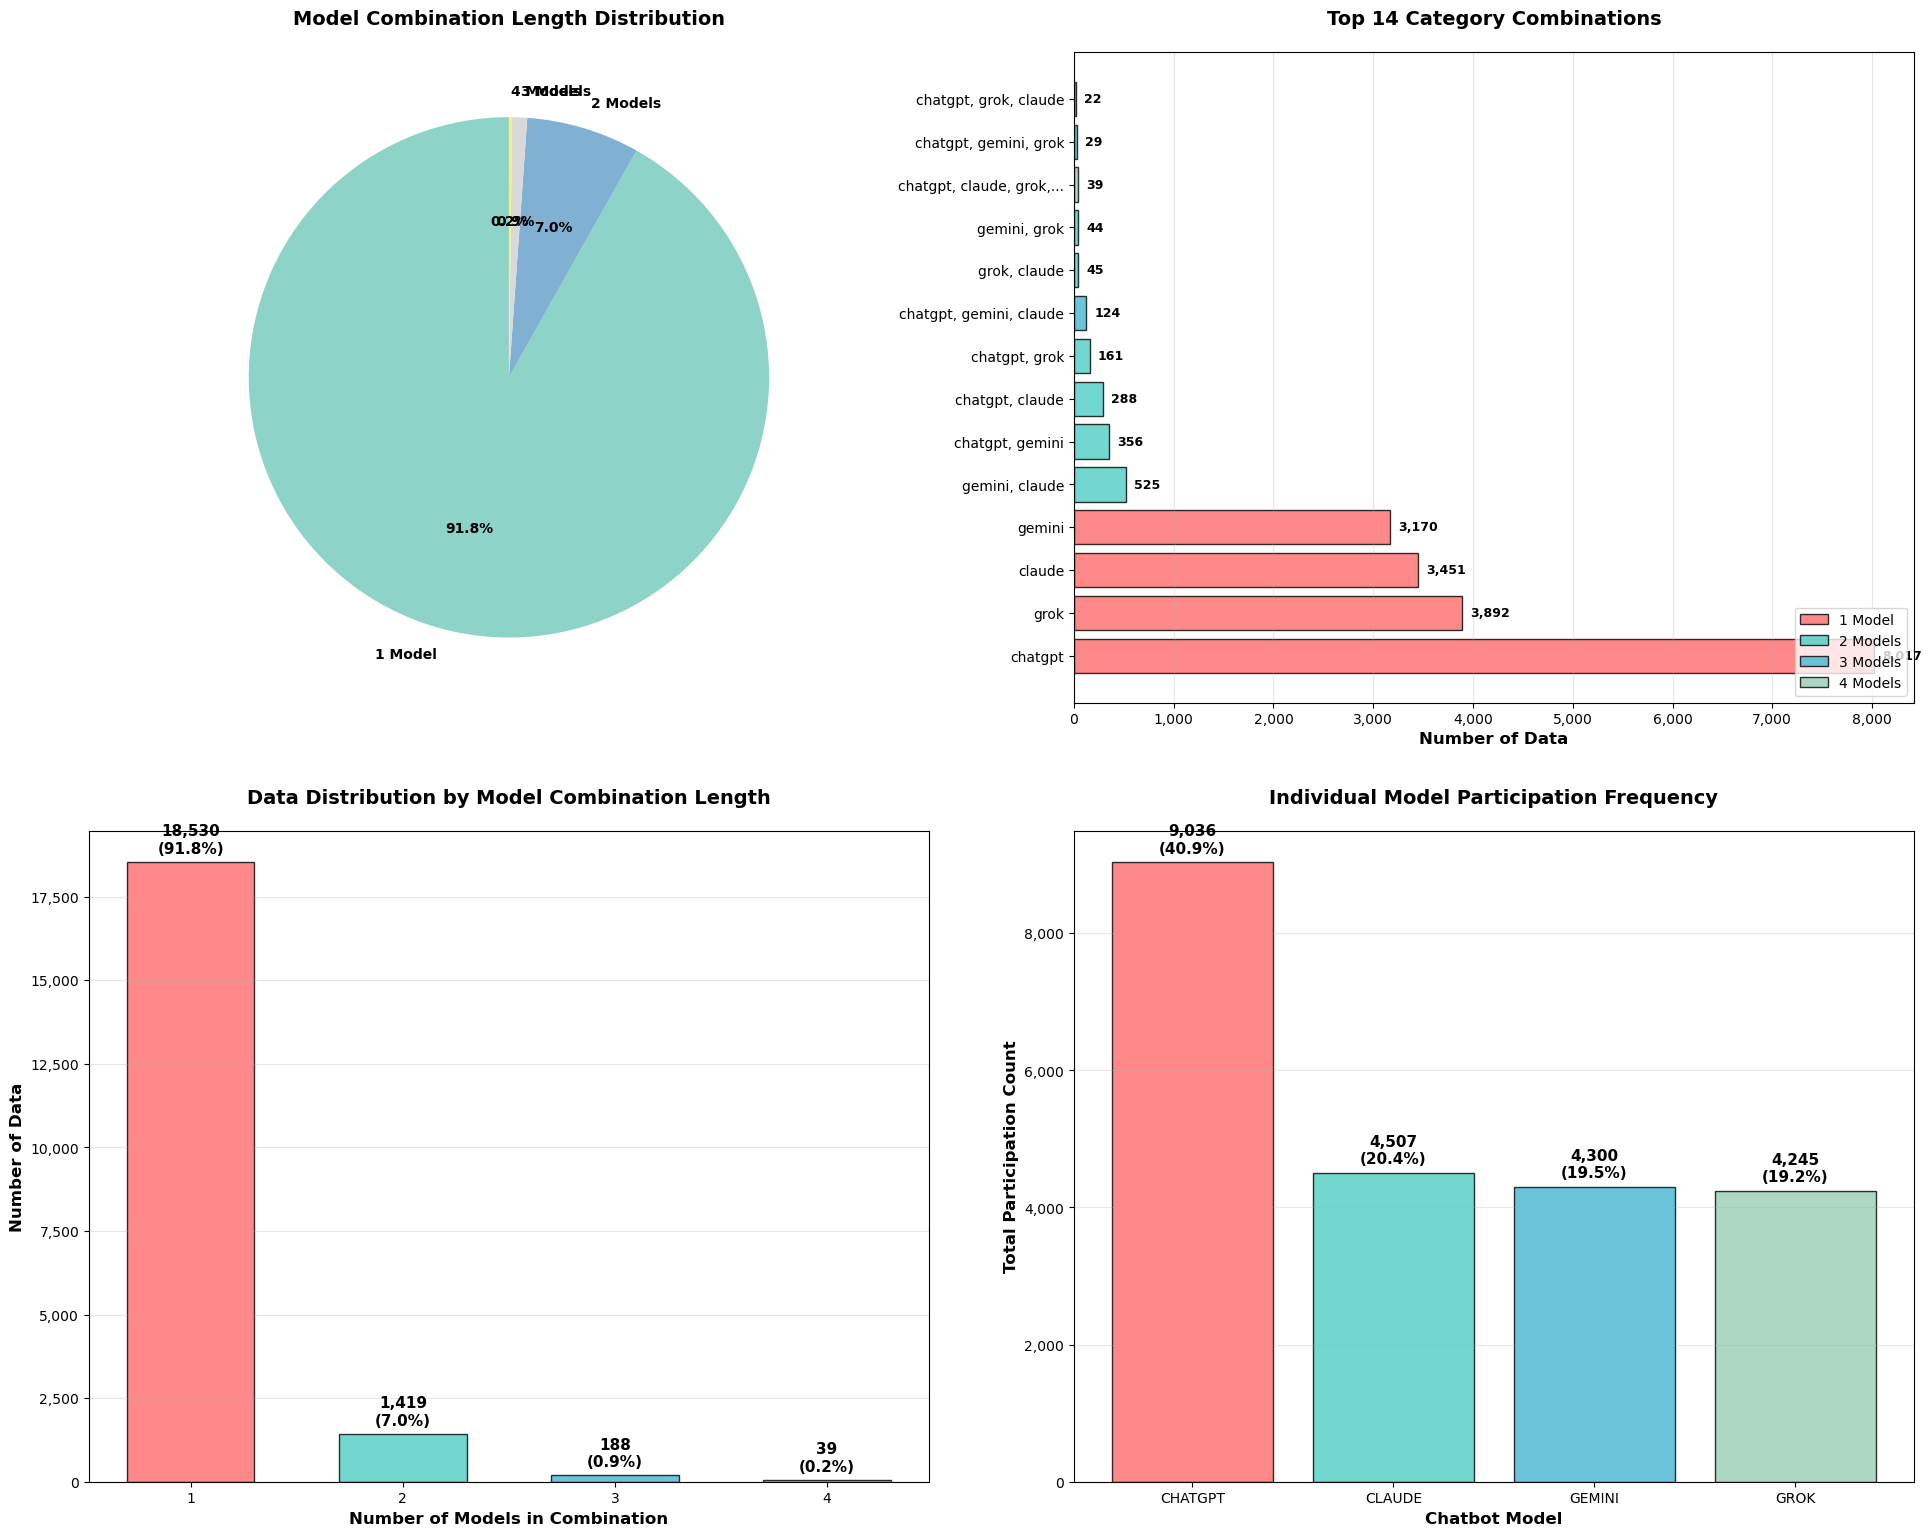


✅ 분석 완료!


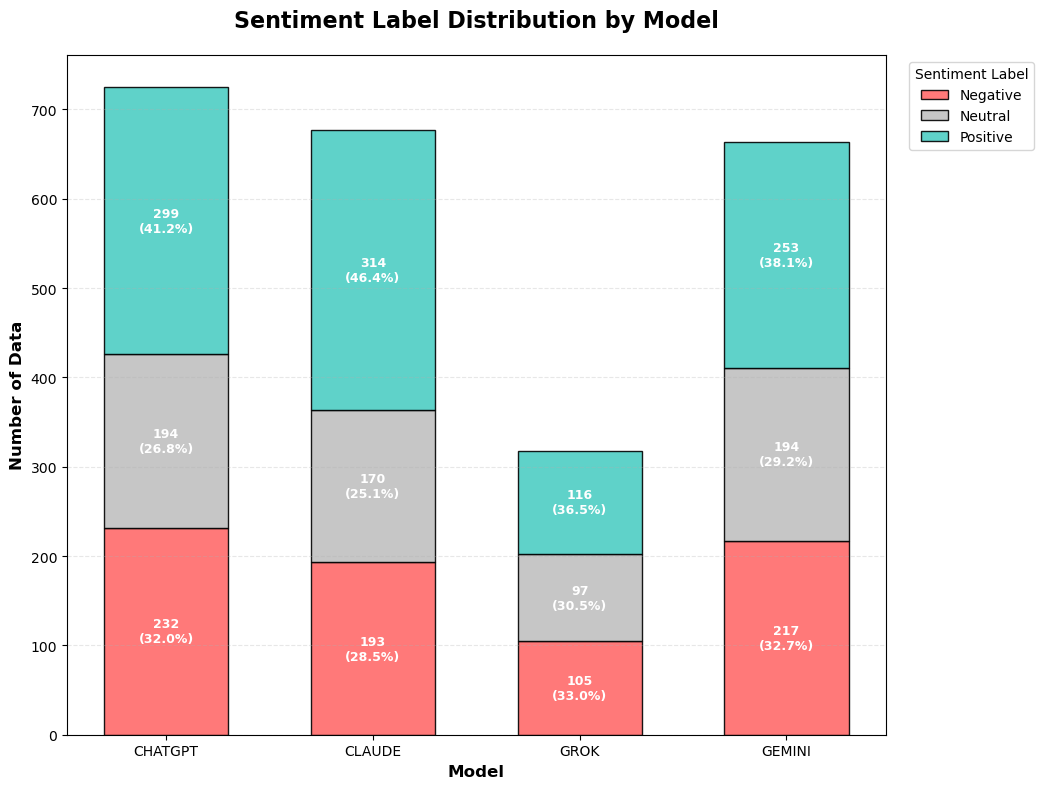

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast


# 데이터 로드
try:
    df = pd.read_csv('data_labelling/labeled_data.csv')
except FileNotFoundError:
    print("파일을 찾을 수 없습니다. 'labeled_data.csv' 경로를 확인해주세요.")
    df = pd.DataFrame()

if not df.empty:
    df.rename(columns={"label(chatgpt,claude,grok,gemini)": "labels"}, inplace=True)

    models = ['chatgpt', 'claude', 'grok', 'gemini']
    sentiment_data = {model: {-1: 0, 0: 0, 1: 0} for model in models}

    for _, row in df.iterrows():
        try:
            categories_str = str(row['category'])
            labels_str = str(row['labels'])

            if categories_str == 'nan' or labels_str == 'nan':
                continue

            categories = ast.literal_eval(categories_str)
            labels = ast.literal_eval(labels_str)

            if isinstance(categories, tuple) and isinstance(labels, list) and len(labels) == 4:
                for i, model in enumerate(models):
                    if model in categories:
                        sentiment = labels[i]
                        if sentiment in [-1, 0, 1]:
                            sentiment_data[model][sentiment] += 1
        except (ValueError, SyntaxError, TypeError):
            continue

    plot_df = pd.DataFrame(sentiment_data).T.fillna(0)
    plot_df.columns = ['Negative', 'Neutral', 'Positive']

    plot_df.index = [m.upper() for m in models]

    fig, ax = plt.subplots(figsize=(12, 8))
    colors = ['#FF6B6B', '#C0C0C0', '#4ECDC4']

    totals = plot_df.sum(axis=1)
    totals[totals == 0] = 1

    bottom = np.zeros(len(plot_df))
    plot_df = plot_df[['Negative', 'Neutral', 'Positive']]

    for i, col in enumerate(plot_df.columns):
        counts = plot_df[col]
        bars = ax.bar(plot_df.index, counts, bottom=bottom, label=col, color=colors[i], alpha=0.9, edgecolor='black', width=0.6)

        for bar, count, total in zip(bars, counts, totals):
            if count > 0:
                percent = f'({(count/total)*100:.1f}%)'
                y_pos = bar.get_y() + bar.get_height() / 2
                # --- 텍스트 색상을 'white'로 변경 ---
                ax.text(bar.get_x() + bar.get_width() / 2, y_pos, f'{int(count)}\n{percent}',
                        ha='center', va='center', color='white', fontsize=9, fontweight='bold')

        bottom += counts

    ax.set_title('Sentiment Label Distribution by Model', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Data', fontsize=12, fontweight='bold')
    ax.legend(title='Sentiment Label', bbox_to_anchor=(1.02, 1), loc='upper left')

    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax.grid(axis='y', linestyle='--', alpha=0.3)


    plt.tight_layout(rect=[0, 0, 0.88, 1])
    plt.show()

else:
    print("데이터프레임이 비어 있어 시각화를 진행할 수 없습니다.")

🚀 Starting Sentiment Analysis...
✅ Data loaded successfully: (20176, 7)

📊 Creating Combined Sentiment Analysis Charts...


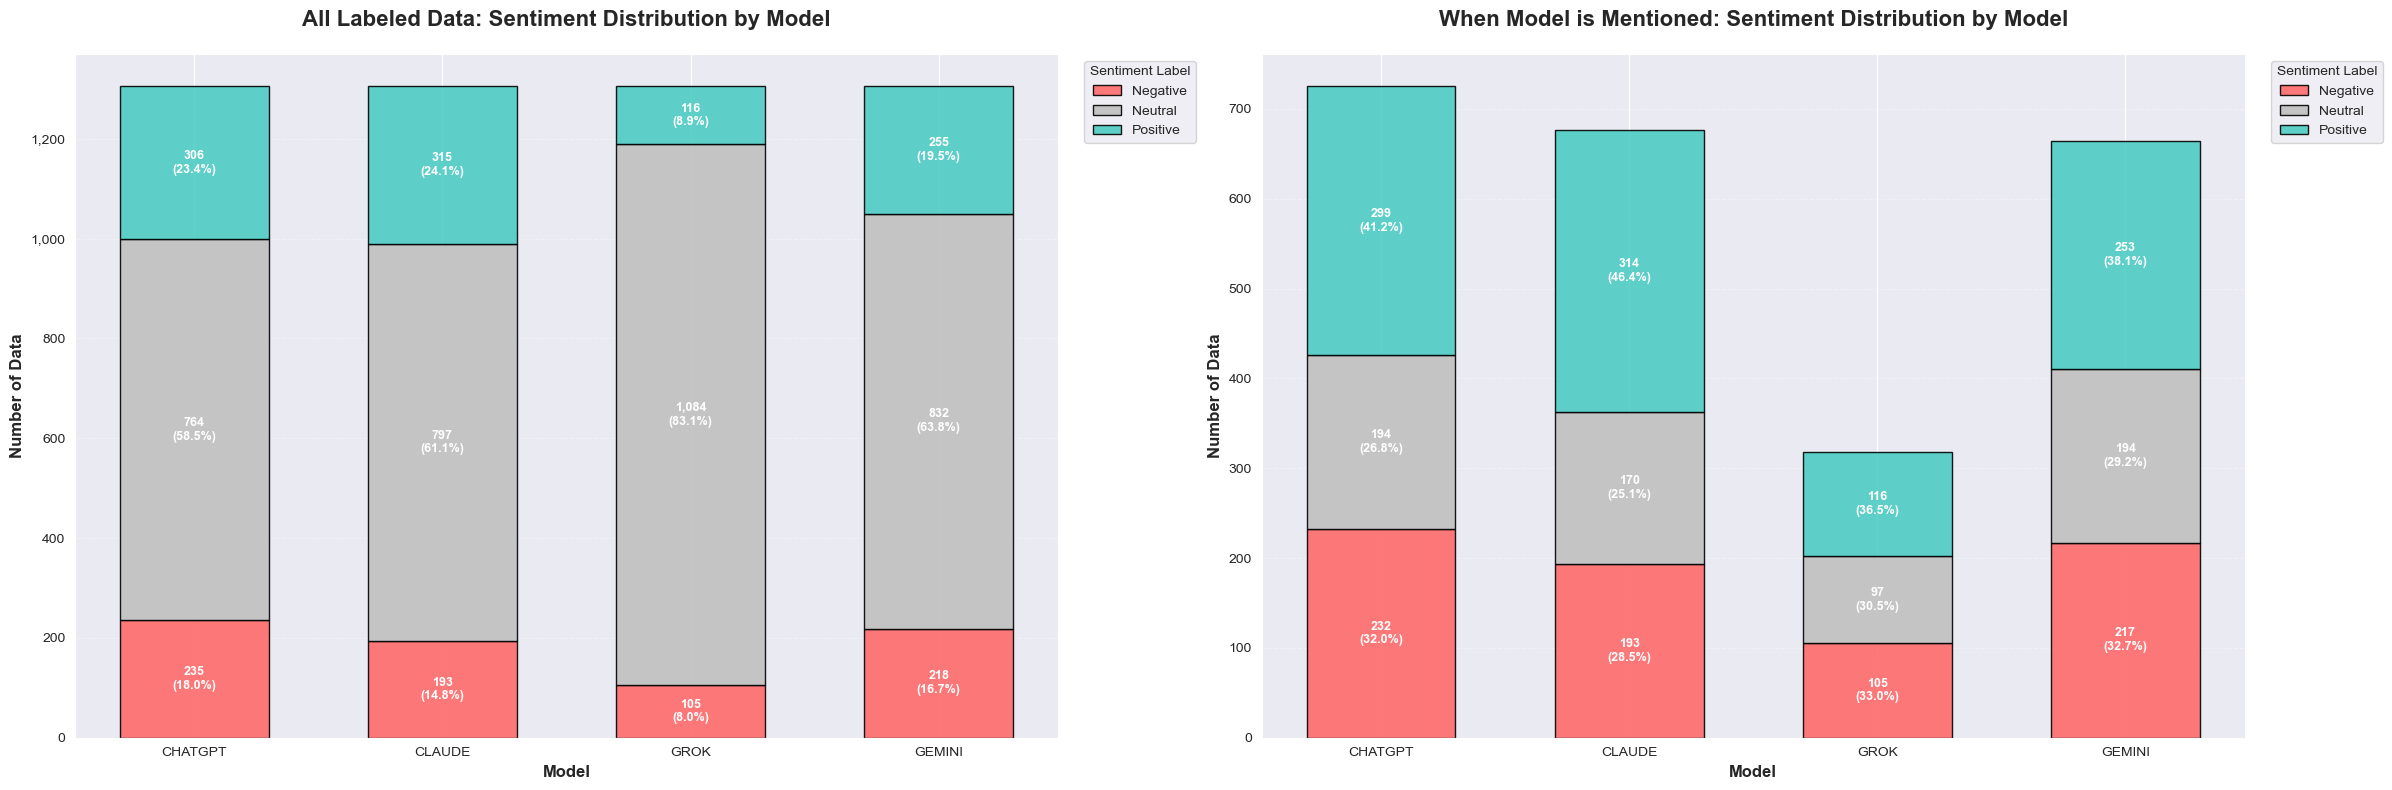


📊 Detailed Sentiment Analysis Report

📈 Total Labeled Data: 20,176 entries

🔍 All Labeled Data - Sentiment Analysis by Model:
  • CHATGPT:
    - Total Data: 1,305 entries
    - Negative: 235 entries (18.0%)
    - Neutral: 764 entries (58.5%)
    - Positive: 306 entries (23.4%)
  • CLAUDE:
    - Total Data: 1,305 entries
    - Negative: 193 entries (14.8%)
    - Neutral: 797 entries (61.1%)
    - Positive: 315 entries (24.1%)
  • GROK:
    - Total Data: 1,305 entries
    - Negative: 105 entries (8.0%)
    - Neutral: 1,084 entries (83.1%)
    - Positive: 116 entries (8.9%)
  • GEMINI:
    - Total Data: 1,305 entries
    - Negative: 218 entries (16.7%)
    - Neutral: 832 entries (63.8%)
    - Positive: 255 entries (19.5%)

🎯 When Model is Mentioned - Sentiment Analysis:
  • CHATGPT:
    - Mentioned Data: 725 entries
    - Negative: 232 entries (32.0%)
    - Neutral: 194 entries (26.8%)
    - Positive: 299 entries (41.2%)
  • CLAUDE:
    - Mentioned Data: 677 entries
    - Negative: 193 e

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import ast


def create_combined_sentiment_chart(df):
    """전체 데이터와 언급된 경우의 sentiment 분포를 subplot으로 표시"""
    models = ['chatgpt', 'claude', 'grok', 'gemini']

    # 1. 전체 라벨링된 데이터의 sentiment 분포
    full_sentiment_data = {model: {-1: 0, 0: 0, 1: 0} for model in models}
    for _, row in df.iterrows():
        try:
            labels_str = str(row['labels'])
            if labels_str == 'nan':
                continue
            labels = ast.literal_eval(labels_str)
            if isinstance(labels, list) and len(labels) == 4:
                for i, model in enumerate(models):
                    sentiment = labels[i]
                    if sentiment in [-1, 0, 1]:
                        full_sentiment_data[model][sentiment] += 1
        except (ValueError, SyntaxError, TypeError):
            continue

    # 2. 모델이 언급된 경우의 sentiment 분포
    mentioned_sentiment_data = {model: {-1: 0, 0: 0, 1: 0} for model in models}
    for _, row in df.iterrows():
        try:
            categories_str = str(row['category'])
            labels_str = str(row['labels'])
            if categories_str == 'nan' or labels_str == 'nan':
                continue
            categories = ast.literal_eval(categories_str)
            labels = ast.literal_eval(labels_str)
            if isinstance(categories, tuple) and isinstance(labels, list) and len(labels) == 4:
                for i, model in enumerate(models):
                    if model in categories:
                        sentiment = labels[i]
                        if sentiment in [-1, 0, 1]:
                            mentioned_sentiment_data[model][sentiment] += 1
        except (ValueError, SyntaxError, TypeError):
            continue

    # subplot 생성
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 8))
    colors = ['#FF6B6B', '#C0C0C0', '#4ECDC4']

    # 좌측: 전체 라벨링된 데이터
    plot_df_full = pd.DataFrame(full_sentiment_data).T.fillna(0)
    plot_df_full.columns = ['Negative', 'Neutral', 'Positive']
    plot_df_full.index = [m.upper() for m in models]

    totals_full = plot_df_full.sum(axis=1)
    totals_full[totals_full == 0] = 1
    bottom_full = np.zeros(len(plot_df_full))

    for i, col in enumerate(plot_df_full.columns):
        counts = plot_df_full[col]
        bars = ax1.bar(plot_df_full.index, counts, bottom=bottom_full, label=col,
                      color=colors[i], alpha=0.9, edgecolor='black', width=0.6)

        for bar, count, total in zip(bars, counts, totals_full):
            if count > 0:
                percent = f'({(count/total)*100:.1f}%)'
                y_pos = bar.get_y() + bar.get_height() / 2
                ax1.text(bar.get_x() + bar.get_width() / 2, y_pos, f'{int(count):,}\n{percent}',
                        ha='center', va='center', color='white', fontsize=9, fontweight='bold')

        bottom_full += counts

    ax1.set_title('All Labeled Data: Sentiment Distribution by Model',
                 fontsize=16, fontweight='bold', pad=20)
    ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Number of Data', fontsize=12, fontweight='bold')
    ax1.legend(title='Sentiment Label', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax1.grid(axis='y', linestyle='--', alpha=0.3)

    # 우측: 모델이 언급된 경우
    plot_df_mentioned = pd.DataFrame(mentioned_sentiment_data).T.fillna(0)
    plot_df_mentioned.columns = ['Negative', 'Neutral', 'Positive']
    plot_df_mentioned.index = [m.upper() for m in models]

    totals_mentioned = plot_df_mentioned.sum(axis=1)
    totals_mentioned[totals_mentioned == 0] = 1
    bottom_mentioned = np.zeros(len(plot_df_mentioned))

    for i, col in enumerate(plot_df_mentioned.columns):
        counts = plot_df_mentioned[col]
        bars = ax2.bar(plot_df_mentioned.index, counts, bottom=bottom_mentioned, label=col,
                      color=colors[i], alpha=0.9, edgecolor='black', width=0.6)

        for bar, count, total in zip(bars, counts, totals_mentioned):
            if count > 0:
                percent = f'({(count/total)*100:.1f}%)'
                y_pos = bar.get_y() + bar.get_height() / 2
                ax2.text(bar.get_x() + bar.get_width() / 2, y_pos, f'{int(count):,}\n{percent}',
                        ha='center', va='center', color='white', fontsize=9, fontweight='bold')

        bottom_mentioned += counts

    ax2.set_title('When Model is Mentioned: Sentiment Distribution by Model',
                 fontsize=16, fontweight='bold', pad=20)
    ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Number of Data', fontsize=12, fontweight='bold')
    ax2.legend(title='Sentiment Label', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
    ax2.grid(axis='y', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    return full_sentiment_data, mentioned_sentiment_data


def print_detailed_statistics(df, full_sentiment_data, mentioned_sentiment_data):
    """상세 통계 출력"""
    print("\n" + "="*70)
    print("📊 Detailed Sentiment Analysis Report")
    print("="*70)

    models = ['chatgpt', 'claude', 'grok', 'gemini']

    print(f"\n📈 Total Labeled Data: {len(df):,} entries")

    print(f"\n🔍 All Labeled Data - Sentiment Analysis by Model:")
    for model in models:
        total_model = sum(full_sentiment_data[model].values())
        if total_model > 0:
            negative_pct = (full_sentiment_data[model][-1] / total_model) * 100
            neutral_pct = (full_sentiment_data[model][0] / total_model) * 100
            positive_pct = (full_sentiment_data[model][1] / total_model) * 100

            print(f"  • {model.upper()}:")
            print(f"    - Total Data: {total_model:,} entries")
            print(f"    - Negative: {full_sentiment_data[model][-1]:,} entries ({negative_pct:.1f}%)")
            print(f"    - Neutral: {full_sentiment_data[model][0]:,} entries ({neutral_pct:.1f}%)")
            print(f"    - Positive: {full_sentiment_data[model][1]:,} entries ({positive_pct:.1f}%)")

    print(f"\n🎯 When Model is Mentioned - Sentiment Analysis:")
    total_mentioned = 0
    for model in models:
        total_model = sum(mentioned_sentiment_data[model].values())
        total_mentioned += total_model
        if total_model > 0:
            negative_pct = (mentioned_sentiment_data[model][-1] / total_model) * 100
            neutral_pct = (mentioned_sentiment_data[model][0] / total_model) * 100
            positive_pct = (mentioned_sentiment_data[model][1] / total_model) * 100

            print(f"  • {model.upper()}:")
            print(f"    - Mentioned Data: {total_model:,} entries")
            print(f"    - Negative: {mentioned_sentiment_data[model][-1]:,} entries ({negative_pct:.1f}%)")
            print(f"    - Neutral: {mentioned_sentiment_data[model][0]:,} entries ({neutral_pct:.1f}%)")
            print(f"    - Positive: {mentioned_sentiment_data[model][1]:,} entries ({positive_pct:.1f}%)")

    print(f"\n📊 Summary:")
    print(f"  • Total Labeled Data: {len(df):,} entries")
    print(f"  • Model Mentioned Data: {total_mentioned:,} entries")
    print(f"  • Mention Rate: {(total_mentioned/len(df)*100):.1f}%")


def compare_sentiment_distributions(full_sentiment_data, mentioned_sentiment_data):
    """전체 vs 언급된 경우의 sentiment 분포 비교"""
    print(f"\n📈 Sentiment Distribution Comparison (All Data vs When Mentioned):")
    models = ['chatgpt', 'claude', 'grok', 'gemini']

    for model in models:
        print(f"\n🤖 {model.upper()}:")

        # 전체 데이터
        full_total = sum(full_sentiment_data[model].values())
        full_positive_rate = (full_sentiment_data[model][1] / full_total * 100) if full_total > 0 else 0

        # 언급된 경우
        mentioned_total = sum(mentioned_sentiment_data[model].values())
        mentioned_positive_rate = (mentioned_sentiment_data[model][1] / mentioned_total * 100) if mentioned_total > 0 else 0

        difference = mentioned_positive_rate - full_positive_rate

        print(f"  • Positive rate in all data: {full_positive_rate:.1f}%")
        print(f"  • Positive rate when mentioned: {mentioned_positive_rate:.1f}%")
        print(f"  • Difference: {difference:+.1f}%p {'📈' if difference > 0 else '📉' if difference < 0 else '➡️'}")


def run_complete_sentiment_analysis():
    """전체 sentiment 분석 실행"""
    print("🚀 Starting Sentiment Analysis...")

    # 데이터 로드
    try:
        df = pd.read_csv('data_labelling/labeled_data.csv')
        print(f"✅ Data loaded successfully: {df.shape}")
    except FileNotFoundError:
        print("❌ File not found. Please check 'labeled_data.csv' path.")
        return

    if df.empty:
        print("❌ DataFrame is empty. Cannot proceed with analysis.")
        return

    # 컬럼명 변경
    df.rename(columns={"label(chatgpt,claude,grok,gemini)": "labels"}, inplace=True)

    # 통합 차트 생성
    print("\n📊 Creating Combined Sentiment Analysis Charts...")
    full_sentiment_data, mentioned_sentiment_data = create_combined_sentiment_chart(df)

    # 상세 통계
    print_detailed_statistics(df, full_sentiment_data, mentioned_sentiment_data)

    # 비교 분석
    compare_sentiment_distributions(full_sentiment_data, mentioned_sentiment_data)

    print("\n✅ Sentiment Analysis Completed!")


# 실행
if __name__ == "__main__":
    run_complete_sentiment_analysis()